the solution of the tasks its in the bottom

Ali Jafar Altaweel
2240006456
7MA2

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Thresholding

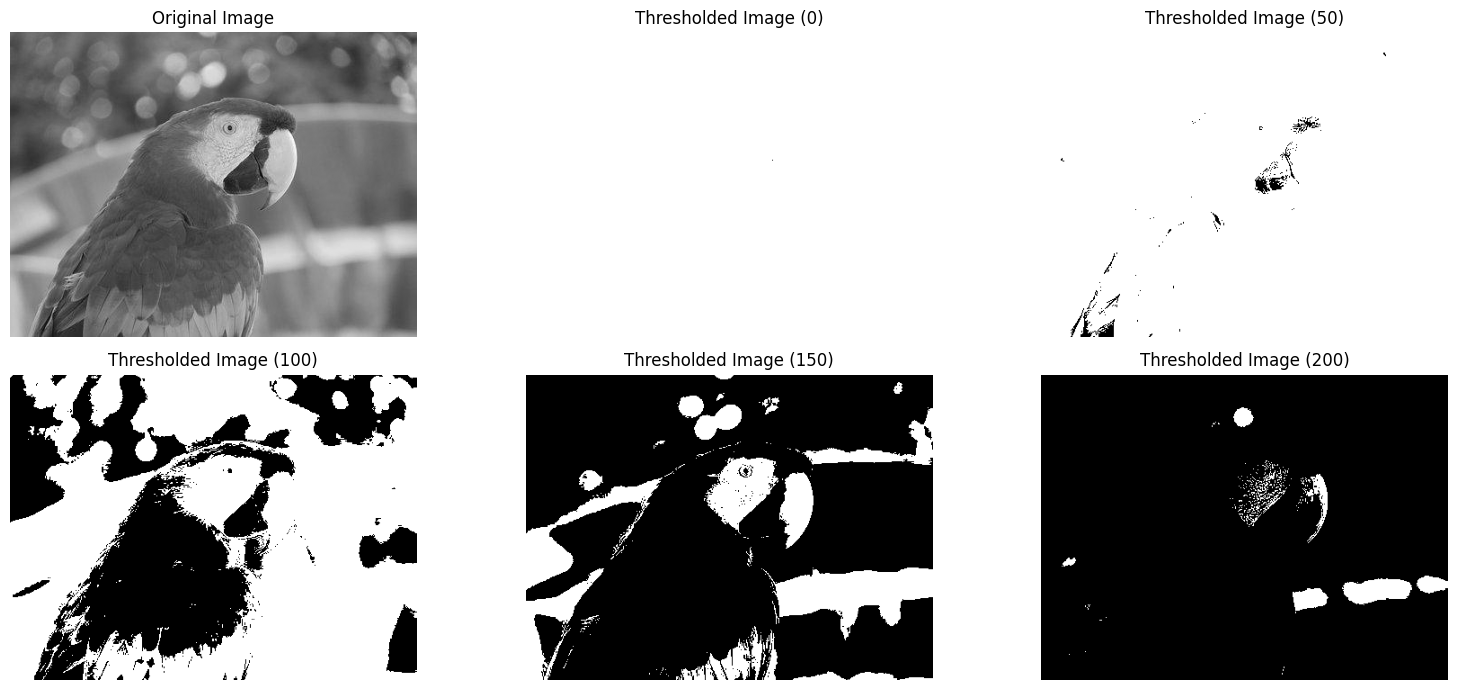

In [2]:
import cv2
# Load the image in grayscale
# img = cv2.imread('../images/Parrot.png', cv2.IMREAD_GRAYSCALE)   # <- manual path
img = cv2.imread('./images/Parrot.png', cv2.IMREAD_GRAYSCALE)      # image kept inside the Lab4 folder
# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]
# Apply thresholding with different threshold values
plt.figure(figsize=(16, 7))
for k, threshold_value in enumerate(threshold_values):
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    # cv2.imshow(f'Thresholded Image ({threshold_value})', thresh)
    plt.subplot(2, 3, k + 2)
    plt.imshow(thresh, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Thresholded Image ({threshold_value})')
    plt.axis('off')
# Display the original image
# cv2.imshow('Original Image', img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image')
plt.axis('off')
plt.tight_layout()
plt.show()

threshold | white pixels | white %
------------------------------------
        0 |       154019 |  100.0%
       50 |       152614 |   99.1%
      100 |        96844 |   62.9%
      150 |        29315 |   19.0%
      200 |         4679 |    3.0%

Otsu threshold : 128.0


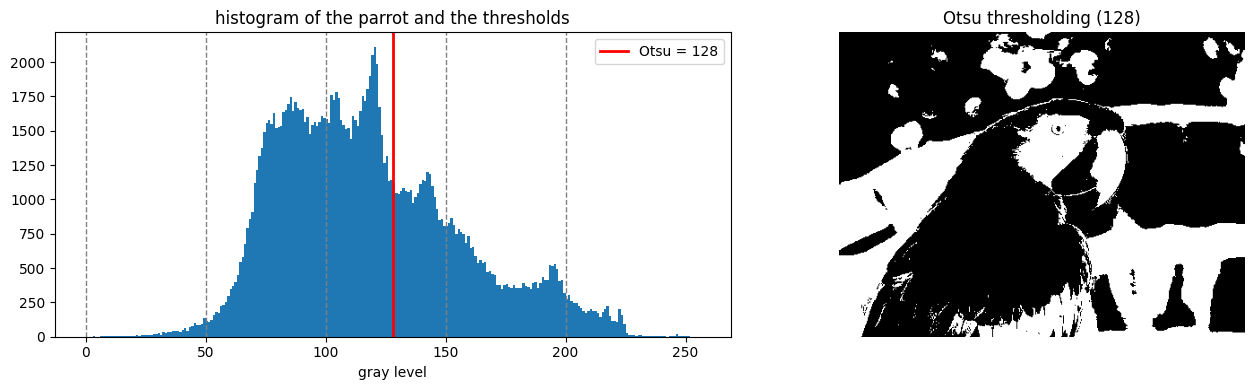

In [3]:
# how much of the image becomes foreground (white) for each threshold
print(f"{'threshold':>9} | {'white pixels':>12} | {'white %':>7}")
print('-' * 36)
for t in threshold_values:
    _, th = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
    print(f"{t:>9} | {int((th == 255).sum()):>12} | {100 * (th == 255).mean():>6.1f}%")

# Otsu picks the threshold automatically from the histogram
otsu_t, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("\nOtsu threshold :", otsu_t)

plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.hist(img.ravel(), bins=256, range=(0, 256))
for t in threshold_values:
    plt.axvline(t, color='gray', ls='--', lw=1)
plt.axvline(otsu_t, color='r', lw=2, label=f'Otsu = {otsu_t:.0f}')
plt.title('histogram of the parrot and the thresholds')
plt.xlabel('gray level')
plt.legend()
plt.subplot(1, 2, 2)
plt.imshow(otsu, cmap='gray')
plt.title(f'Otsu thresholding ({otsu_t:.0f})')
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Histogram processing

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, img_as_float
from skimage import exposure

In [5]:
img = data.moon()
print("moon :", img.shape, img.dtype, " min/max =", img.min(), img.max())

moon : (512, 512) uint8  min/max = 0 255


In [6]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))
print("2nd percentile =", p2, " 98th percentile =", p98)
print("after stretching : min/max =", img_rescale.min(), img_rescale.max())

2nd percentile = 78.0  98th percentile = 129.0
after stretching : min/max = 0 255


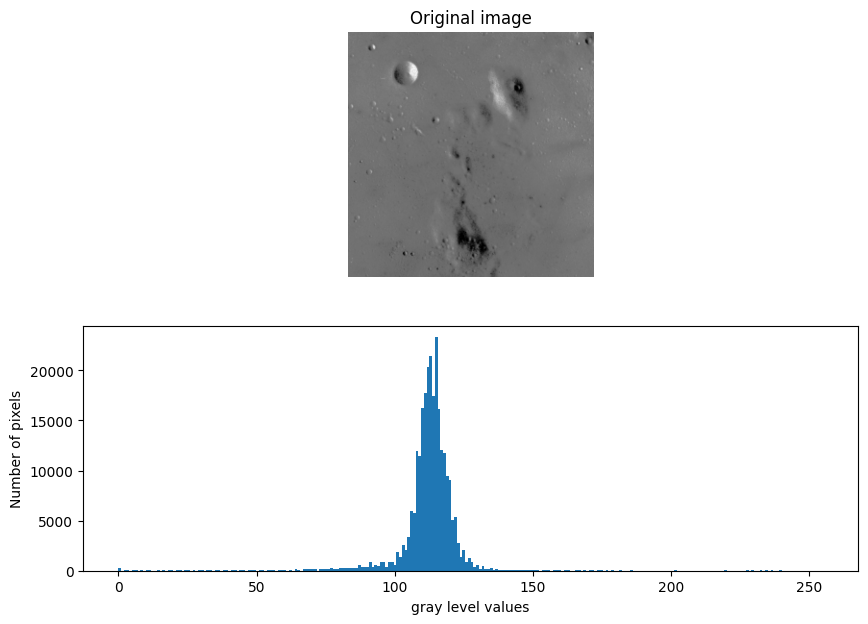

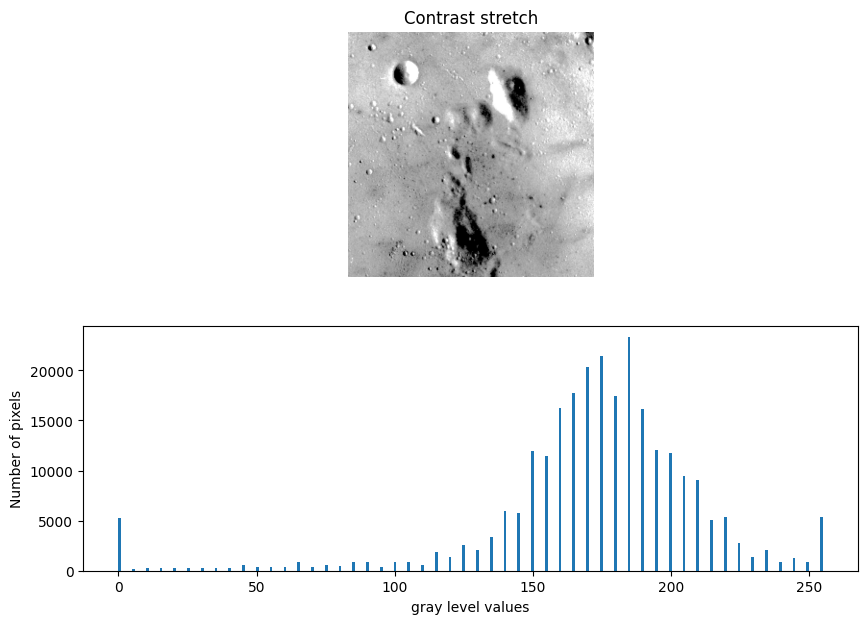

In [7]:
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

In [8]:
def show_with_hist(image, title, bins_range=(0, 255)):
    """Image on the left, histogram + cumulative histogram on the right."""
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.5))
    a1.imshow(image, cmap='gray', vmin=bins_range[0], vmax=bins_range[1])
    a1.set_title(title)
    a1.axis('off')
    a2.hist(image.ravel(), bins=256, range=bins_range)
    a2.set_xlabel('gray level values')
    a2.set_ylabel('Number of pixels')
    cdf, centers = exposure.cumulative_distribution(image, 256)
    a3 = a2.twinx()
    a3.plot(centers, cdf, 'r')
    a3.set_ylabel('cumulative fraction', color='r')
    a3.set_ylim(0, 1.02)
    a2.set_title(f'histogram  (used range {image.min()} - {image.max()})')
    plt.tight_layout()
    plt.show()

## 3. Student tasks

### Task 1
Using the same "moon image" Rescale intensity values to include all the intensities that fall within the 3rd and 80th percentiles, and plot the histogram

### Task 2
Using the same "moon image" and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

### Task 3
Use the rocket (as reference) and Chelsea images (from skimage.data) and implement histogram matching

### Task 1 Solution – Contrast stretching between the 3rd and 80th percentiles

3rd percentile = 87.0   80th percentile = 118.0
pixels below p3  (become 0)   : 7464 (2.8%)
pixels above p80 (become 255) : 43340 (16.5%)


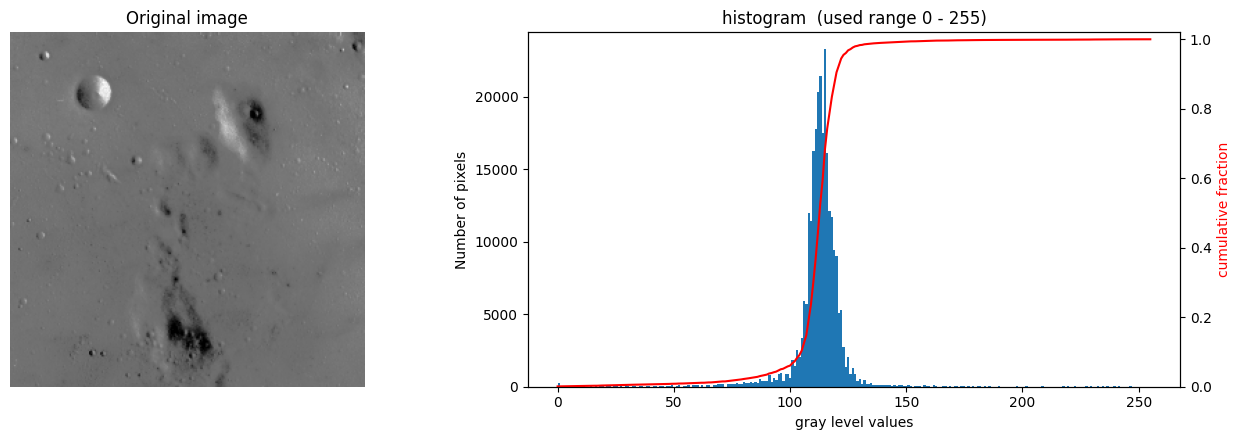

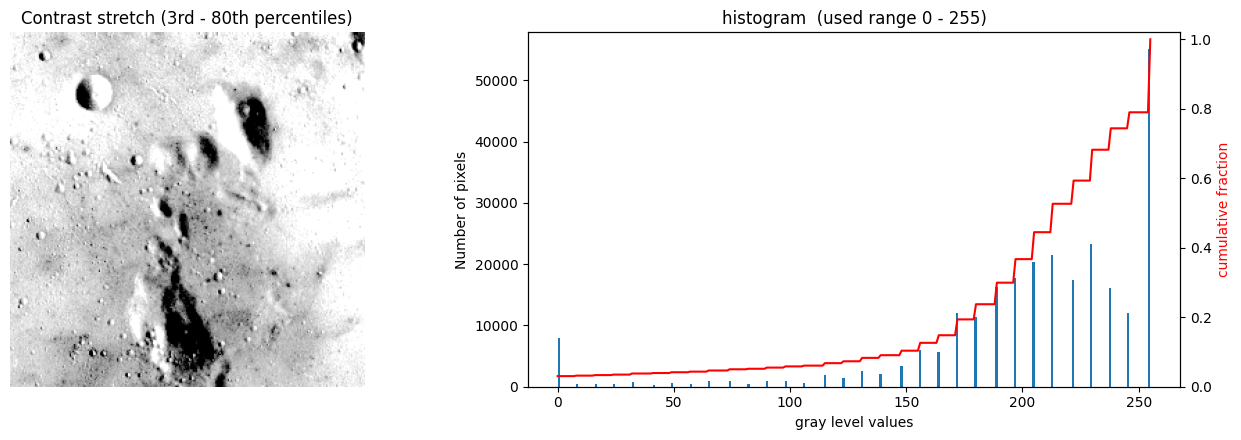

In [9]:
p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))

print("3rd percentile =", p3, "  80th percentile =", p80)
print("pixels below p3  (become 0)   :", int((img < p3).sum()), f"({100 * (img < p3).mean():.1f}%)")
print("pixels above p80 (become 255) :", int((img > p80).sum()), f"({100 * (img > p80).mean():.1f}%)")

show_with_hist(img, 'Original image')
show_with_hist(img_rescale_3_80, 'Contrast stretch (3rd - 80th percentiles)')

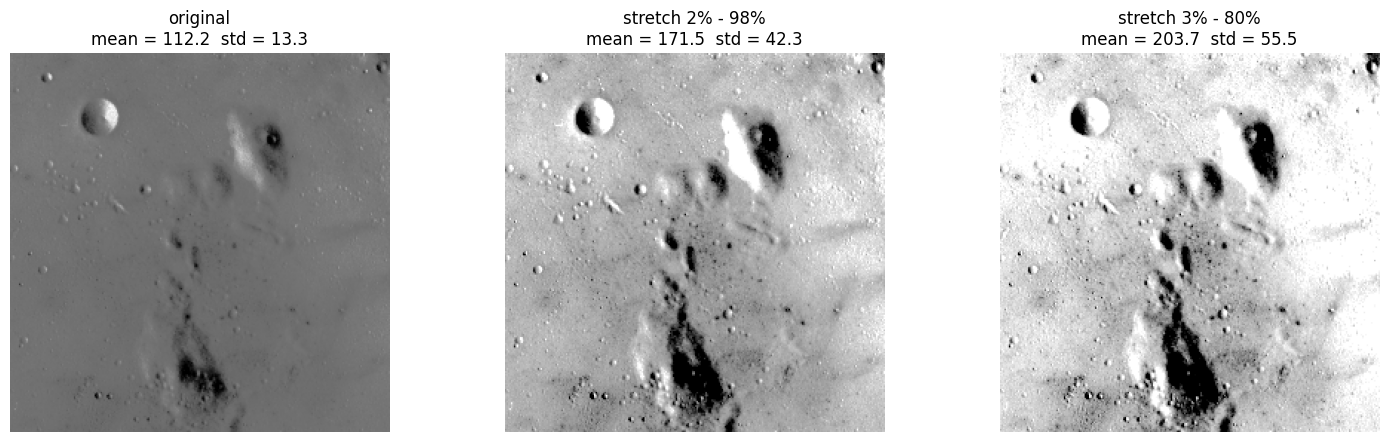

In [10]:
# comparison with the 2 - 98 stretch of the manual
plt.figure(figsize=(15, 4.5))
for k, (im, t) in enumerate([(img, 'original'), (img_rescale, 'stretch 2% - 98%'),
                             (img_rescale_3_80, 'stretch 3% - 80%')]):
    plt.subplot(1, 3, k + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(f'{t}\nmean = {im.mean():.1f}  std = {im.std():.1f}')
    plt.axis('off')
plt.tight_layout()
plt.show()

Explanation: the 80th percentile is much lower than the 98th, so the input range that gets stretched over 0-255 is narrower. The mid tones gain more contrast, but the brightest 20% of the pixels are all clipped to 255, which shows up as a tall spike at the right end of the histogram and as burned-out white areas on the moon surface.

### Task 2 Solution – Histogram equalization

equalize_hist output : float64  min/max = 0.0009 1.0


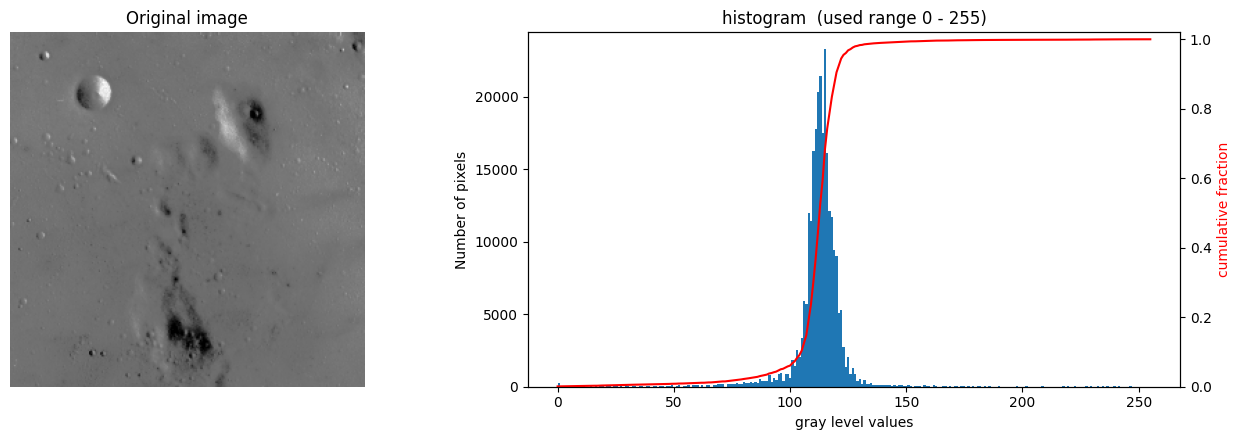

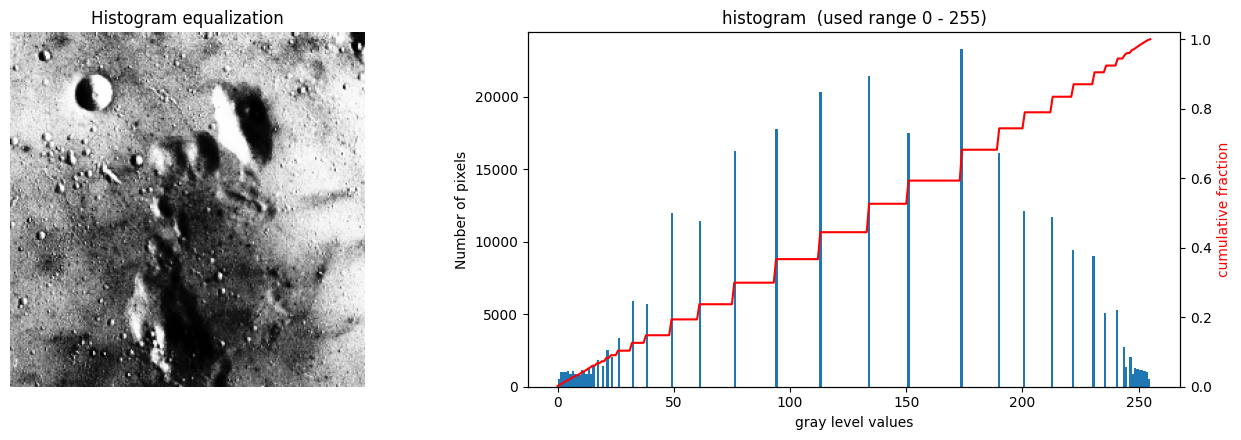

In [11]:
img_eq = exposure.equalize_hist(img)           # returns floats in [0, 1]
print("equalize_hist output :", img_eq.dtype, " min/max =", round(img_eq.min(), 4), round(img_eq.max(), 4))

# convert back to 0..255 so the histogram can be compared with the original one
from skimage import img_as_ubyte
img_eq_u8 = img_as_ubyte(img_eq)

show_with_hist(img, 'Original image')
show_with_hist(img_eq_u8, 'Histogram equalization')

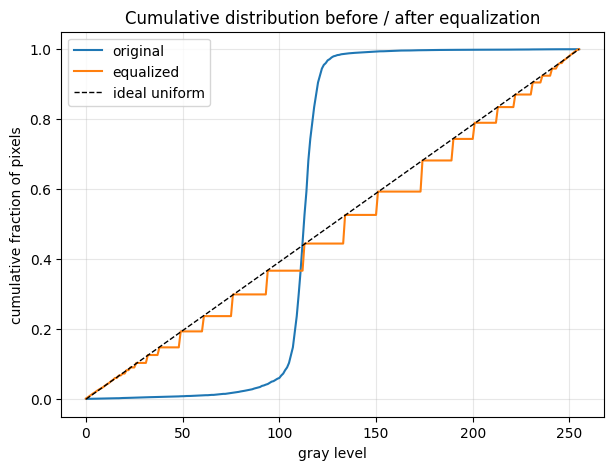

std original  : 13.3
std equalized : 73.9
max distance of the equalized CDF from the ideal line : 0.085


In [12]:
# the cumulative histogram of the equalized image is (almost) a straight line
cdf_o, c_o = exposure.cumulative_distribution(img, 256)
cdf_e, c_e = exposure.cumulative_distribution(img_eq_u8, 256)

plt.figure(figsize=(7, 5))
plt.plot(c_o, cdf_o, label='original')
plt.plot(c_e, cdf_e, label='equalized')
plt.plot([0, 255], [0, 1], 'k--', lw=1, label='ideal uniform')
plt.xlabel('gray level')
plt.ylabel('cumulative fraction of pixels')
plt.title('Cumulative distribution before / after equalization')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("std original  :", round(float(img.std()), 1))
print("std equalized :", round(float(img_eq_u8.std()), 1))
print("max distance of the equalized CDF from the ideal line :",
      round(float(np.abs(cdf_e - c_e / 255).max()), 3))

Explanation: `equalize_hist` maps every gray level through the cumulative distribution of the image, so the output levels are spread over the whole range and the cumulative histogram becomes close to a straight line. The histogram is not perfectly flat, because pixels that share one input level must share one output level, so equalization can only move the bars apart, never split them.

### Task 3 Solution – Histogram matching

reference (rocket) : (427, 640, 3) uint8
image (chelsea)    : (300, 451, 3) uint8


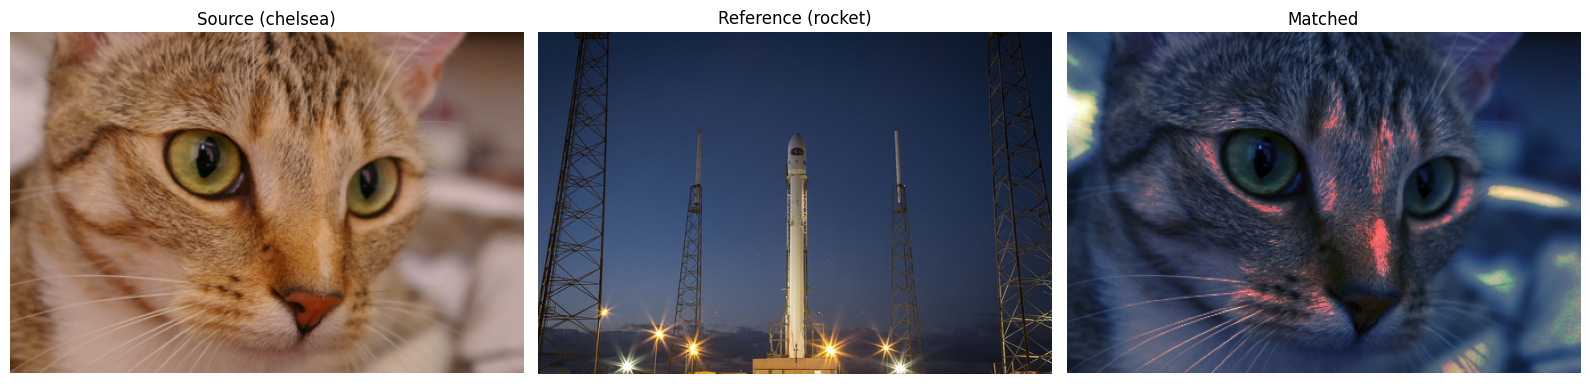

In [13]:
from skimage.exposure import match_histograms

reference = data.rocket()
image = data.chelsea()
print("reference (rocket) :", reference.shape, reference.dtype)
print("image (chelsea)    :", image.shape, image.dtype)

matched = match_histograms(image, reference, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (im, t) in zip(axes, [(image, 'Source (chelsea)'), (reference, 'Reference (rocket)'),
                              (matched, 'Matched')]):
    ax.imshow(im.astype(np.uint8))
    ax.set_title(t)
    ax.axis('off')
plt.tight_layout()
plt.show()

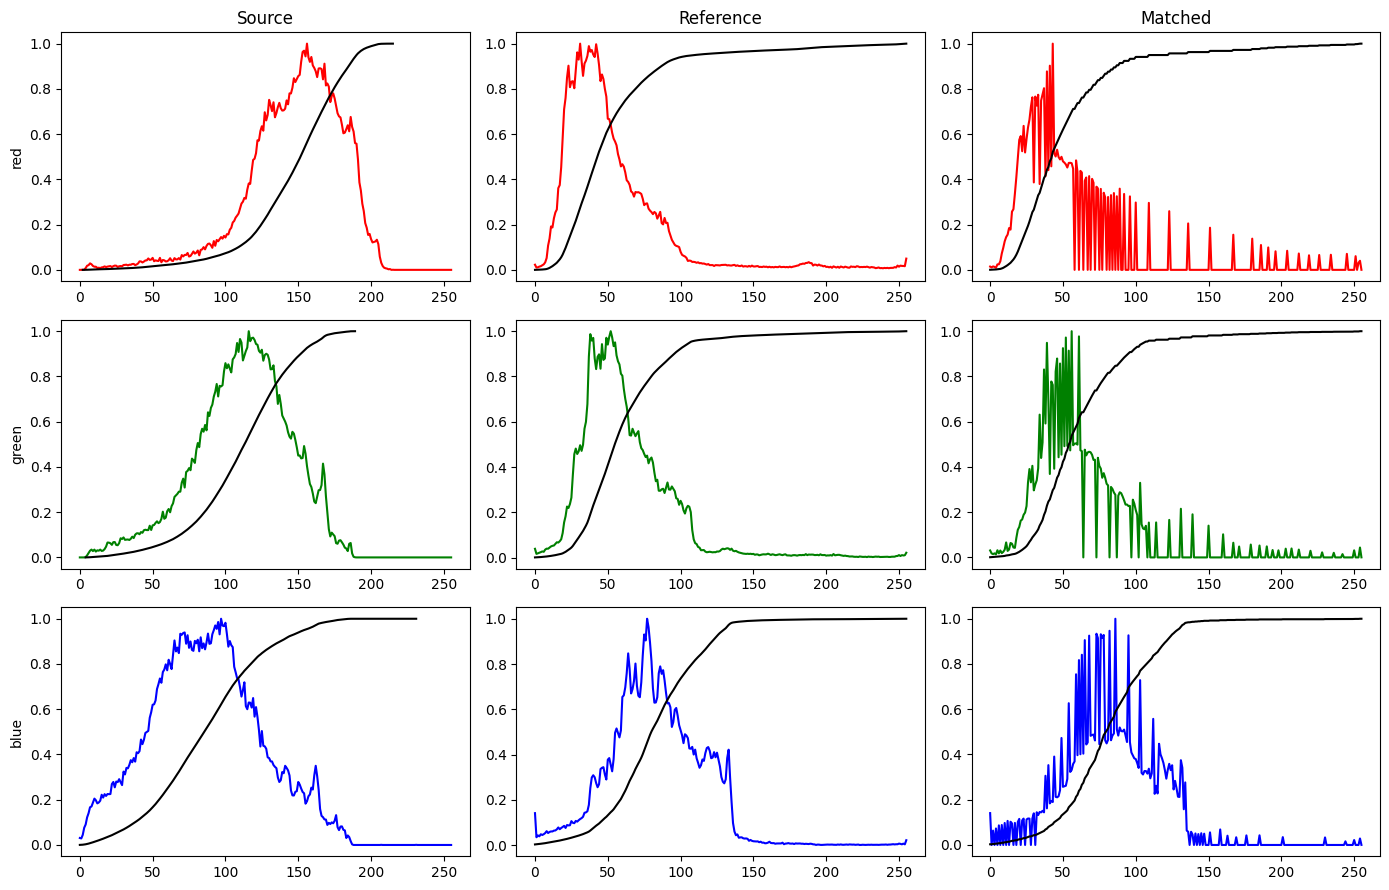

In [14]:
# histograms and cumulative histograms of every channel
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
colors = ['red', 'green', 'blue']
for col, (im, t) in enumerate([(image, 'Source'), (reference, 'Reference'), (matched, 'Matched')]):
    axes[0, col].set_title(t)
    for ch, color in enumerate(colors):
        hist, bins = exposure.histogram(im[..., ch].astype(np.uint8), source_range='dtype')
        axes[ch, col].plot(bins, hist / hist.max(), color=color)
        cdf, cbins = exposure.cumulative_distribution(im[..., ch].astype(np.uint8))
        axes[ch, col].plot(cbins, cdf, 'k')
        axes[ch, 0].set_ylabel(color)
plt.tight_layout()
plt.show()

In [15]:
# numeric check : after matching, the per-channel statistics follow the reference
print(f"{'channel':>7} | {'source mean':>11} | {'reference mean':>14} | {'matched mean':>12} | {'max CDF gap':>11}")
print('-' * 70)
for ch, name in enumerate(['R', 'G', 'B']):
    cdf_r, b_r = exposure.cumulative_distribution(reference[..., ch])
    cdf_m, b_m = exposure.cumulative_distribution(matched[..., ch].astype(np.uint8))
    gap = np.abs(np.interp(np.arange(256), b_r, cdf_r) - np.interp(np.arange(256), b_m, cdf_m)).max()
    print(f"{name:>7} | {image[..., ch].mean():>11.1f} | {reference[..., ch].mean():>14.1f} | "
          f"{matched[..., ch].mean():>12.1f} | {gap:>11.3f}")

channel | source mean | reference mean | matched mean | max CDF gap
----------------------------------------------------------------------
      R |       147.7 |           52.3 |         52.1 |       0.019
      G |       111.4 |           61.3 |         60.8 |       0.017
      B |        86.8 |           82.3 |         81.7 |       0.015


Explanation: histogram matching maps each channel of the source through its own CDF and then through the inverse CDF of the reference, so the matched cat keeps its shapes and edges but takes the color distribution of the rocket image. The cumulative histograms of the matched image line up with those of the reference, while the two images still have different sizes, which the method does not care about since it only uses the histograms.